In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("C:\\Users\\User\\Downloads\\archive (3)\\Mall_Customers.zip")

In [3]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.shape

(200, 5)

In [5]:
df.size

1000

In [6]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [8]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [9]:
df.rename(columns={"Genre": "Gender"},inplace=True)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [10]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.drop("CustomerID",axis=1,inplace=True)
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


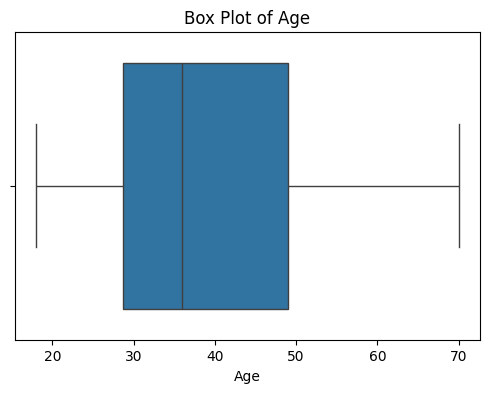

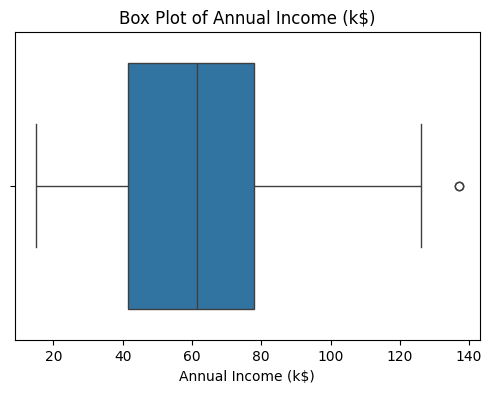

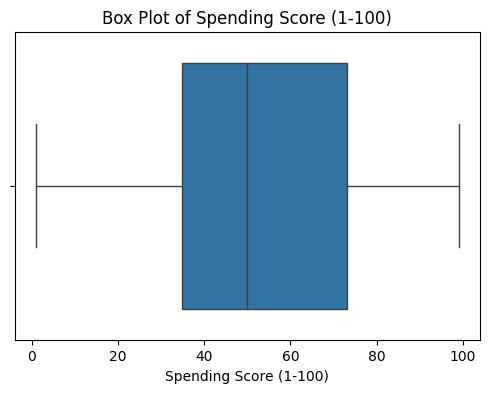

In [13]:
numerical_columns = df.select_dtypes(include=np.number).columns
for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot of {col}")
    plt.show()

In [14]:

    Q1 = df["Annual Income (k$)"].quantile(0.25)
    Q3 = df["Annual Income (k$)"].quantile(0.75)
    IQR = Q3-Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df=df[(df["Annual Income (k$)"] >= lower) &(df["Annual Income (k$)"] <= upper)] 

<Axes: ylabel='Annual Income (k$)'>

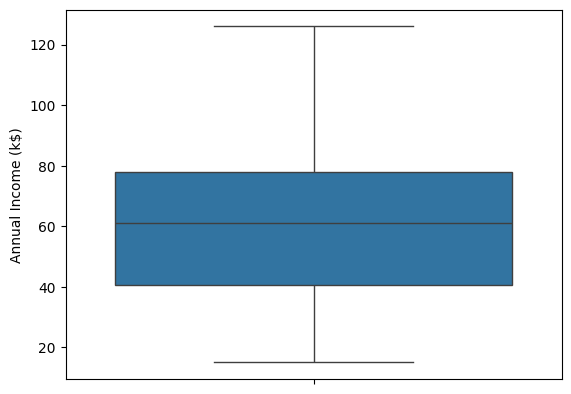

In [15]:
sns.boxplot(df["Annual Income (k$)"])

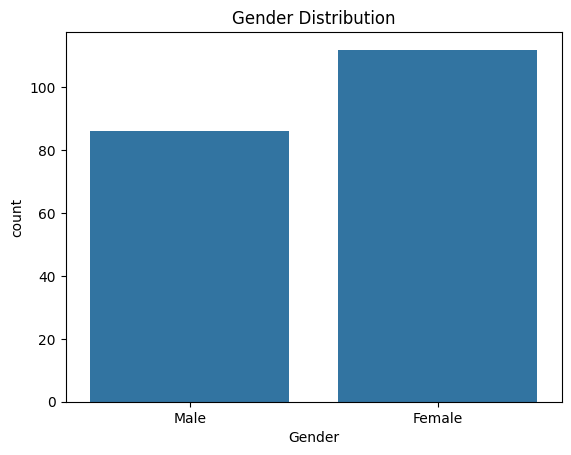

In [16]:
sns.countplot(x="Gender",data=df)
plt.title("Gender Distribution")
plt.show()

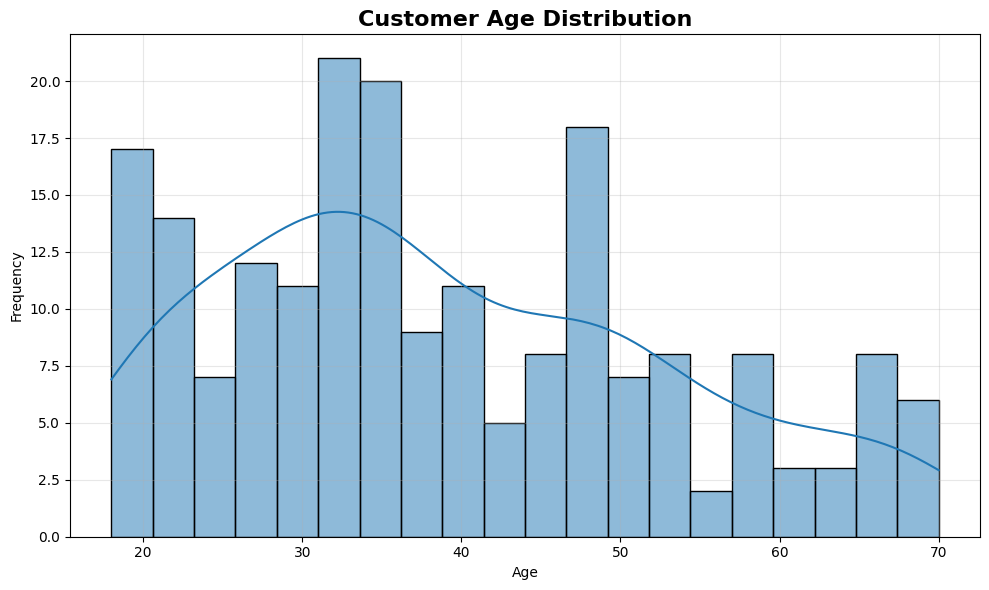

In [17]:
plt.figure(figsize=(10,6))
sns.histplot(df["Age"],bins=20,kde=True,edgecolor="black")
plt.title("Customer Age Distribution",fontsize=16,fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

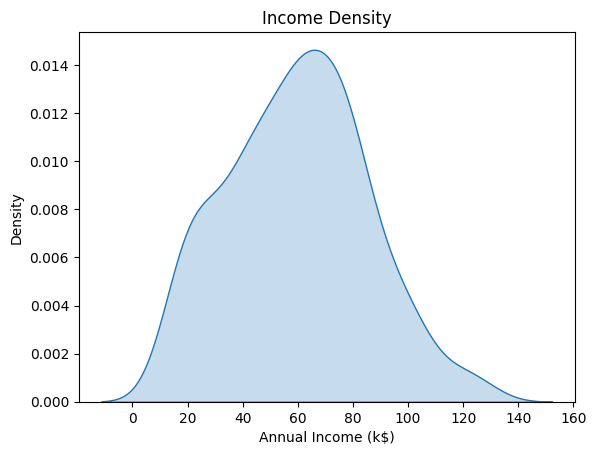

In [18]:
sns.kdeplot(df["Annual Income (k$)"],fill=True)
plt.title("Income Density")
plt.show()

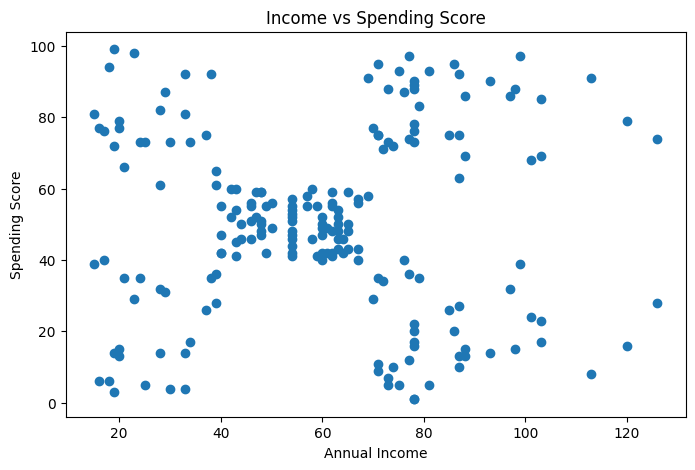

In [19]:
plt.figure(figsize=(8,5))
plt.scatter(df["Annual Income (k$)"],df["Spending Score (1-100)"])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Income vs Spending Score")
plt.show()

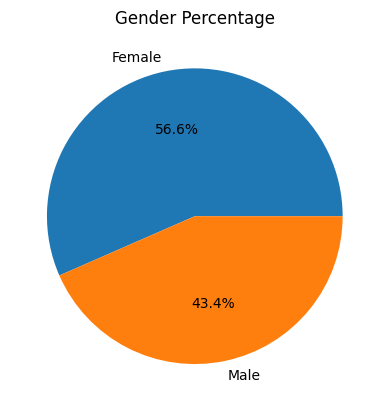

In [20]:
gender_counts = df["Gender"].value_counts()
plt.pie(gender_counts,labels=["Female","Male"],autopct="%1.1f%%")
plt.title("Gender Percentage")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

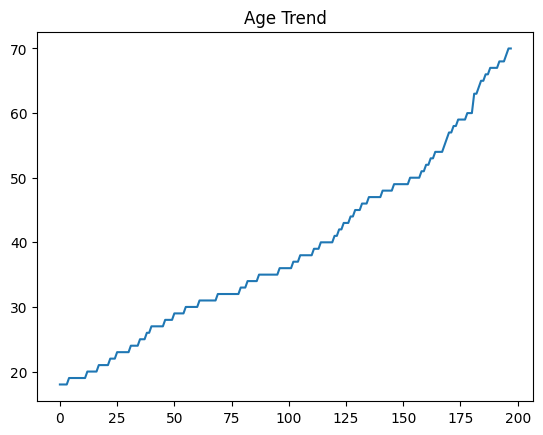

In [21]:
df["Age"].sort_values().reset_index(drop=True).plot()
plt.title("Age Trend")
plt.show

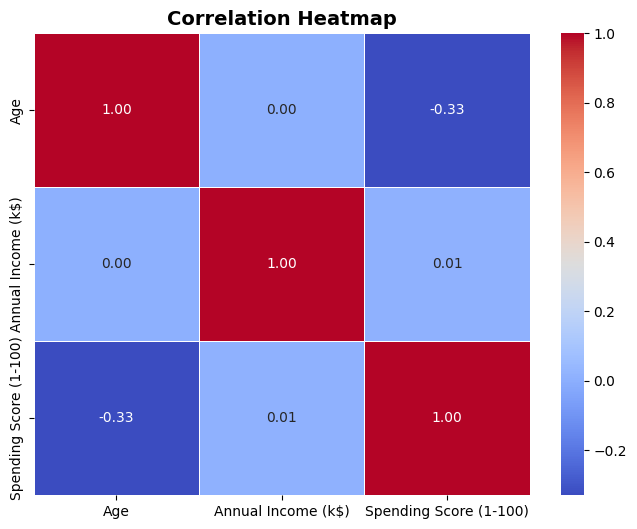

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt=".2f",cmap="coolwarm",linewidth=0.5)
plt.title("Correlation Heatmap", fontsize=14,fontweight="bold")
plt.show()

In [23]:
df["Gender"]=df["Gender"].map({"Male":0,"Female":1})
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


In [25]:
X=df[["Annual Income (k$)","Spending Score (1-100)"]]

In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-1.77917141, -0.43598941],
       [-1.77917141,  1.19941337],
       [-1.73944701, -1.72094874],
       [-1.73944701,  1.04366072],
       [-1.69972262, -0.39705125],
       [-1.69972262,  1.00472256],
       [-1.65999822, -1.72094874],
       [-1.65999822,  1.70560947],
       [-1.62027383, -1.83776323],
       [-1.62027383,  0.84896992],
       [-1.62027383, -1.40944345],
       [-1.62027383,  1.90030028],
       [-1.58054943, -1.37050529],
       [-1.58054943,  1.04366072],
       [-1.58054943, -1.44838161],
       [-1.58054943,  1.12153705],
       [-1.54082504, -0.59174206],
       [-1.54082504,  0.61534095],
       [-1.46137625, -0.82537103],
       [-1.46137625,  1.86136212],
       [-1.42165185, -0.59174206],
       [-1.42165185,  0.88790808],
       [-1.38192745, -1.75988691],
       [-1.38192745,  0.88790808],
       [-1.26275427, -1.40944345],
       [-1.26275427,  1.23835153],
       [-1.26275427, -0.70855655],
       [-1.26275427,  0.42065014],
       [-1.22302987,

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

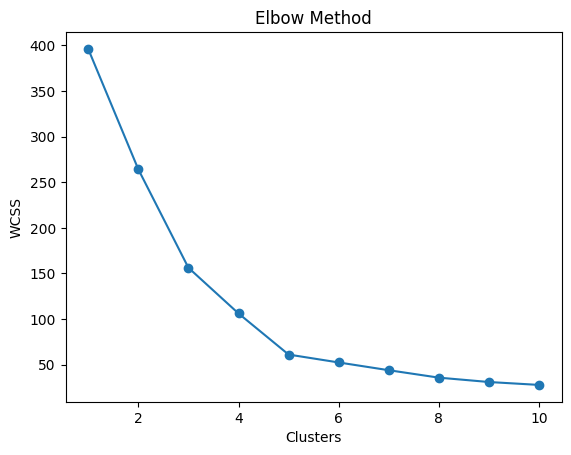

In [28]:
plt.plot(range(1,11),wcss,marker="o")
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

In [31]:
kmeans = KMeans(n_clusters=5,random_state=42,n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df["Cluster"] = clusters

In [50]:
df.sample(5)

,Gender,Age,Annual Income (k$),Spending Score (1-100),Clusters,Cluster
60,0,70,46,56,3,3
30,0,60,30,4,4,4
125,1,31,70,77,2,2
178,0,59,93,14,1,1
24,1,54,28,14,4,4


In [51]:
df["Cluster"].value_counts()

Cluster
3    80
2    38
1    35
4    23
0    22
Name: count, dtype: int64

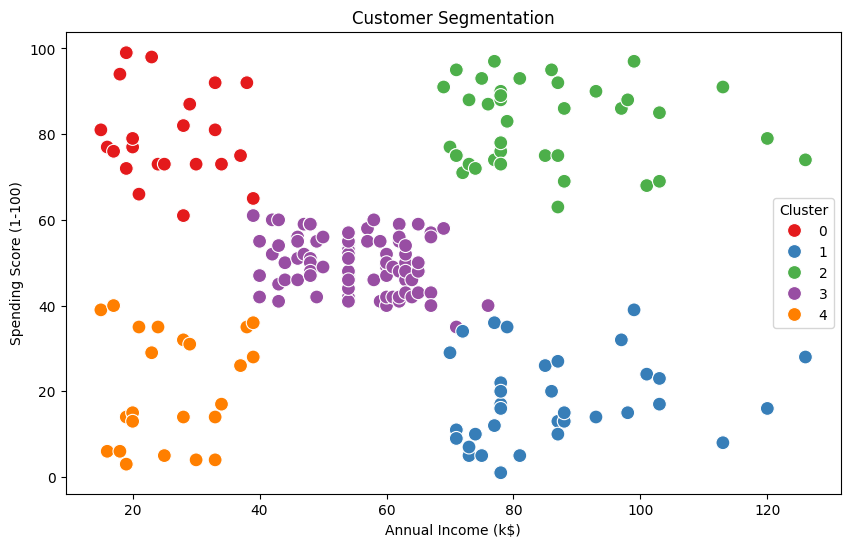

In [52]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df["Annual Income (k$)"],y=df["Spending Score (1-100)"],hue=df["Cluster"],palette="Set1",s=100)
plt.title("Customer Segmentation")
plt.show()

In [53]:
centres = scaler.inverse_transform(kmeans.cluster_centers_)
print(centres)

[[25.72727273 79.36363636]
 [86.34285714 17.57142857]
 [85.21052632 82.10526316]
 [55.0875     49.7125    ]
 [26.30434783 20.91304348]]


In [54]:
score = silhouette_score(X_scaled,clusters)
print("silhouette_score :", score)

silhouette_score : 0.5599199830769206


In [55]:
df.groupby("Cluster").mean()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Clusters
Cluster,,,,,
0,0.590909,25.272727,25.727273,79.363636,0.0
1,0.485714,40.914286,86.342857,17.571429,1.0
2,0.552632,32.763158,85.210526,82.105263,2.0
3,0.587500,42.937500,55.087500,49.712500,3.0
4,0.608696,45.217391,26.304348,20.913043,4.0


In [56]:
new_customer = [[55, 50]]
new_scaled = scaler.transform(new_customer)
cluster = kmeans.predict(new_scaled)
customer_types = {
    0:"Young customers with low income but high spending",
    1:"High-income customers with low spending",
    2:"High-income customers with high spending (Premium Customers)",
    3:"Average customers with moderate income and spending",
    4:"Low-income customers with low spending"
}
print("Customer belongs to Cluster:",cluster[0])
print("Customer Type:", customer_types[cluster[0]])

Customer belongs to Cluster: 3
Customer Type: Average customers with moderate income and spending
